In [71]:
# to_save, to_load = False, True
session_file = "./tmp/TIC_265527315_EA.ipynb.pkl"

# # load/save the notebook session
# # https://dill.readthedocs.io/en/latest/
# if True: 
#     import dill
#     import sys
#     if "../" not in sys.path:  # to get my usual helpers at base dir
#         sys.path.append("../")
#     if "../eb_with_diff_sb_period/etv/" not in sys.path:  # for etvp
#         sys.path.append("../eb_with_diff_sb_period/etv/")
#     dill.load_module(session_file)
#     print(f"Notebook session loaded from  {session_file}")

# if True:  # save the notebook session
#     import dill
#     dill.dump_module(session_file)
#     print(f"Notebook session saved in {session_file}")


Notebook session saved in ./tmp/TIC_265527315_EA.ipynb.pkl


In [1]:
import sys
if "../" not in sys.path:  # to get my usual helpers at base dir
    sys.path.append("../")

import lightkurve as lk
from lightkurve_ext import of_sector, of_sectors, of_2min_cadences
import lightkurve_ext as lke
from lightkurve_ext import TransitTimeSpec, TransitTimeSpecList
import lightkurve_ext_tess as lket
import lightkurve_ext_pg as lke_pg
import lightkurve_ext_pg_runner as lke_pg_runner
import tic_plot as tplt

import asyncio_compat

import math
import re
import warnings

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as matplotlib

import pandas as pd
import astropy as astropy
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time, TimeDelta
from astropy.io import fits

from matplotlib.ticker import (FormatStrFormatter, AutoMinorLocator)

from importlib import reload # useful during development to reload packages

from IPython.display import display, HTML, Javascript, clear_output

display(HTML("<style>.container { width:99% !important; }</style>"))  # Jupyter 6
display(HTML("<style>.jp-Notebook { --jp-notebook-max-width: 98%; }</style>"))  # Jupyter 7


# No longer works in Jupyter 7+
display(Javascript("""
// export notebook url to Python for bokeh-based interactive features
if (window["IPython"] != null) {
  IPython.notebook.kernel.execute(`notebook_url = "${window.location.origin}"`);
} else {
  console.warn("IPython js object not available (in Jupyter 7). Hardcode notebook_url in the notebook itself instead.")
}
"""));
notebook_url = "localhost:8888"

%matplotlib inline

# data cache config
lk_download_dir = '../data'
if hasattr(lk, "conf"):  # default download dir
    lk.conf.cache_dir = lk_download_dir

# make markdown table aligned to the left of the cell output (instead of center)
display(HTML("<style>table {margin-left: 4ch;}</style>"))

C:\pkg\_winNonPortables\miniforge3\envs\my_lk_plus4\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(
C:\pkg\_winNonPortables\miniforge3\envs\my_lk_plus4\Lib\site-packages\lightkurve\config\__init__.py:119: UserWarning: The default Lightkurve cache directory, used by download(), etc., has been moved to C:\Users\SL\.lightkurve\cache. Please move all the files in the legacy directory C:\Users\SL\.lightkurve-cache to the new location and remove the legacy directory. Refer to https://lightkurve.github.io/lightkurve/reference/config.html#default-cache-directory-migration for more information.
  warnings.warn(


<IPython.core.display.Javascript object>

# TIC 265527315 Analysis (EA)

- new VSX entry


## TESS Data

In [2]:
tic = 265527315

sr = lk.search_lightcurve(f"TIC{tic}", )  # author="SPOC", cadence="short"
sr_unfiltered = sr  # keep a copy
sr = lke.filter_by_priority(sr, author_priority = ["SPOC", "TESS-SPOC", ])  # 
sr = sr[np.isin(sr.author, ["SPOC", "TESS-SPOC"])]  # for uniformity, only 1 sector (98) with QLP-only data 
sr = lke._sort_chronologically(sr)

astropy.table.pprint.conf.max_lines = 100  # to print all rows
display(sr)

# Note: only 1 sector of ready made lightcurve
# if needed, lightcurves can be created from sectors 37, 63, 64 (and in the future 90, 99, 100, 101)
lcc_tess = sr.download_all()
lcc_tess

#,mission,year,author,exptime,target_name,distance,proposal_id
,,,,s,,arcsec,
0,TESS Sector 01,2018,TESS-SPOC,1800,265527315,0.0,N/A
1,TESS Sector 27,2020,TESS-SPOC,600,265527315,0.0,N/A
2,TESS Sector 67,2023,TESS-SPOC,200,265527315,0.0,N/A
3,TESS Sector 94,2025,SPOC,120,265527315,0.0,N/A
4,TESS Sector 95,2025,SPOC,120,265527315,0.0,N/A
5,TESS Sector 101,2026,SPOC,120,265527315,0.0,N/A
6,TESS Sector 102,2026,SPOC,120,265527315,0.0,N/A
7,TESS Sector 103,2026,SPOC,120,265527315,0.0,N/A
8,TESS Sector 104,2026,SPOC,120,265527315,0.0,N/A


LightCurveCollection of 9 objects:
    0: <TessLightCurve LABEL="TIC 265527315" SECTOR=1 AUTHOR=TESS-SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 265527315" SECTOR=27 AUTHOR=TESS-SPOC FLUX_ORIGIN=pdcsap_flux>
    2: <TessLightCurve LABEL="TIC 265527315" SECTOR=67 AUTHOR=TESS-SPOC FLUX_ORIGIN=pdcsap_flux>
    3: <TessLightCurve LABEL="TIC 265527315" SECTOR=94 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    4: <TessLightCurve LABEL="TIC 265527315" SECTOR=95 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    5: <TessLightCurve LABEL="TIC 265527315" SECTOR=101 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    6: <TessLightCurve LABEL="TIC 265527315" SECTOR=102 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    7: <TessLightCurve LABEL="TIC 265527315" SECTOR=103 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    8: <TessLightCurve LABEL="TIC 265527315" SECTOR=104 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>

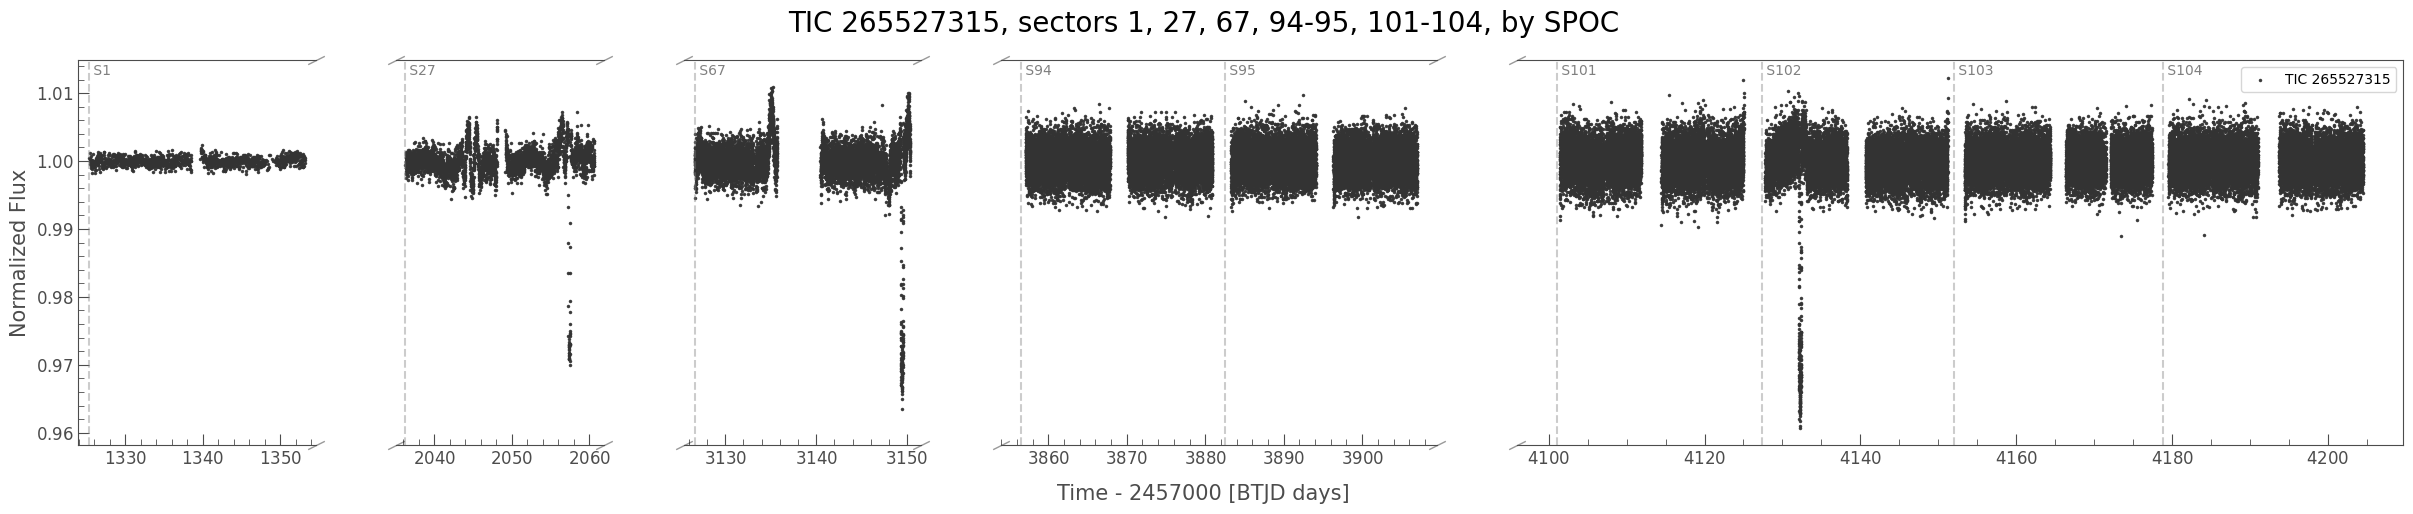

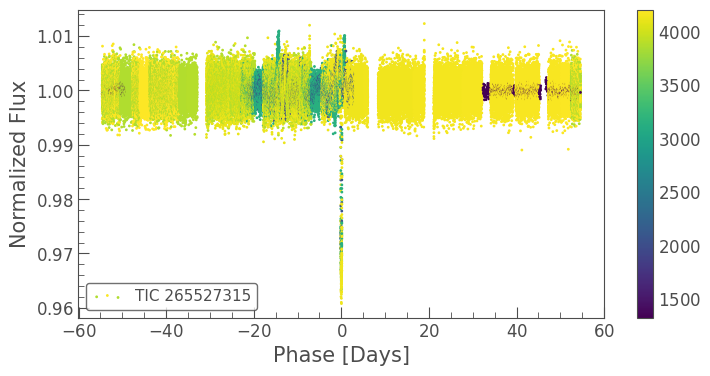

In [3]:
_lc = lke.stitch(lcc_tess, ignore_incompatible_column_warning=True)  # , corrector_func=lambda lc: lc.select_flux("sap_flux").normalize()

axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
axs[0].get_figure().suptitle(f"{_lc.label}, sectors {lke.abbrev_sector_list(_lc)}, by {_lc.author}", fontsize=20);
# [ax.set_ylim(0.97, 1.01) for ax in axs];


_lc_f = _lc.fold(period=109.202, epoch_time=Time(4132.25, format="btjd"), )  # wrap_phase= # rough initial epoch / period to gauge usefulness of the data
ax = tplt.scatter(_lc_f, c=_lc_f.time_original.value);
# ax.set_ylim(0.97, 1.01);
# ax.set_xlim(5, 10); ax.set_ylim(0.95, None);  # zoomed around Min II

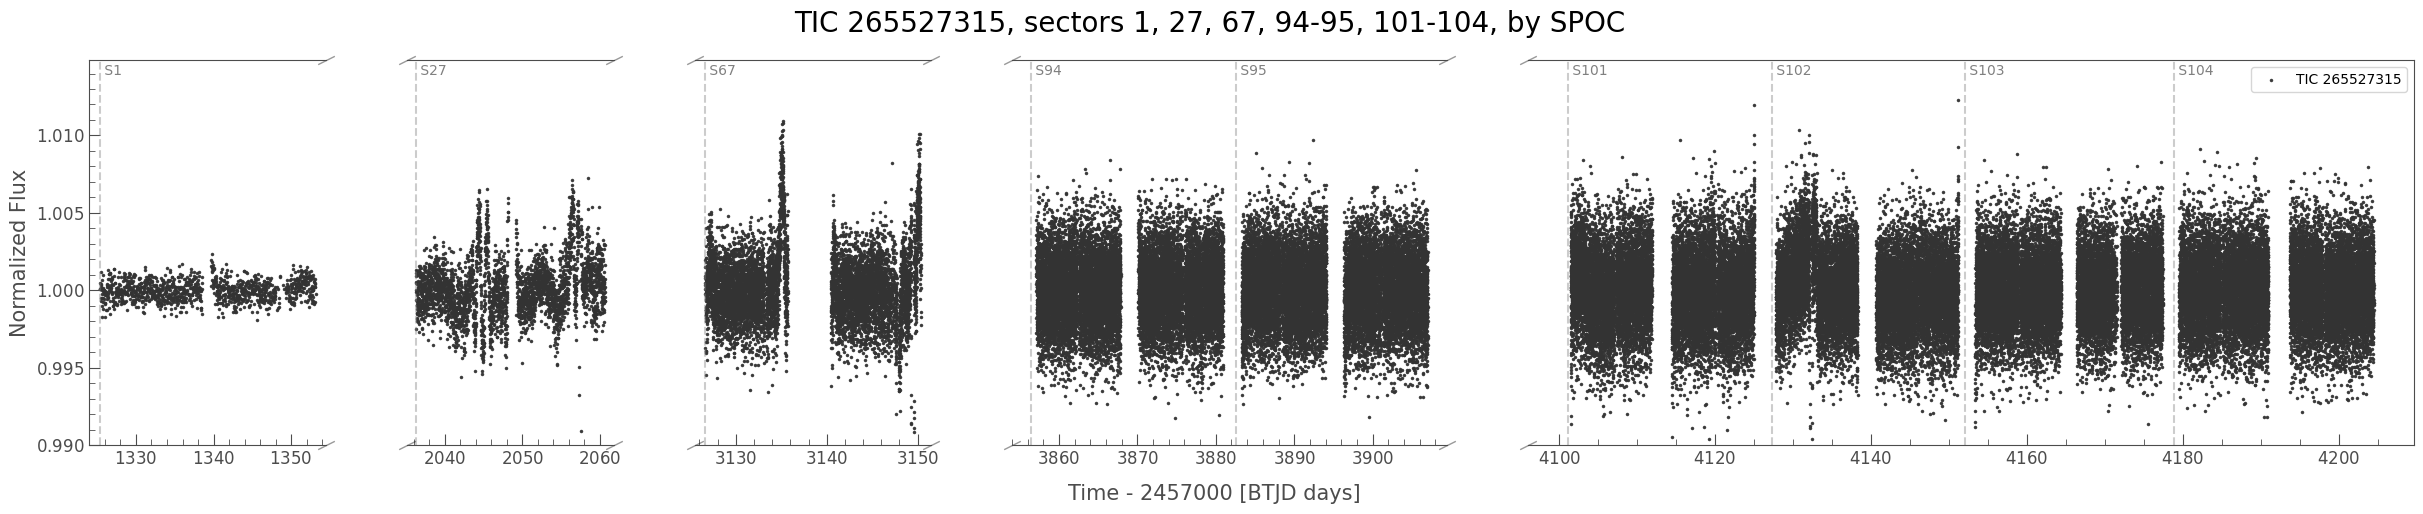

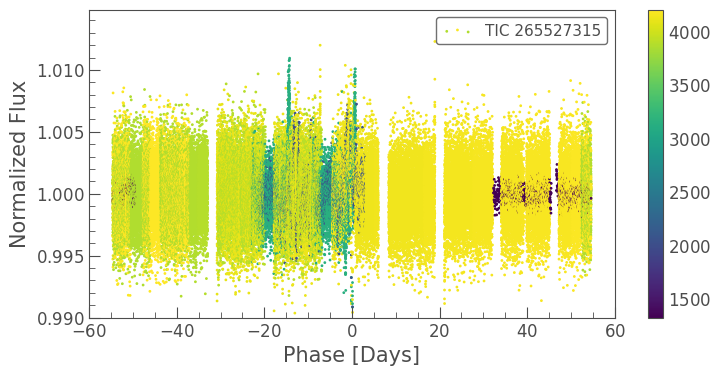

In [5]:
# truncating the eclipses to see out of eclipse variation

_ylim = (0.99, None)
axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
axs[0].get_figure().suptitle(f"{_lc.label}, sectors {lke.abbrev_sector_list(_lc)}, by {_lc.author} ", fontsize=20);
[ax.set_ylim(*_ylim) for ax in axs];

ax = tplt.scatter(_lc_f, c=_lc_f.time_original.value);
ax.set_ylim(*_ylim);

## Gaia DR3 info (coordinate, etc.)

In [6]:
# reload(lke)
# reload (lket)
rs_all_cols, rs, rs_html  = lket.search_gaiadr3_of_tics(tic, radius_arcsec=15, magnitude_range=None,  pm_error_factor=None, pm_range_fraction=None, pm_range_minimum=None, 
                                                        calc_separation_from_first_row=True,  # assuming the first row is the target, it'd calculate more accurately the separation for Gaia DR3 Main
                                                        compact_columns=True, also_return_html=True, also_return_astrophysical=False, verbose_html=True, include_nss_summary_in_html=False)
display(HTML(rs_html))

# from Gaia DR3
target_coord = SkyCoord(rs[0]["RAJ2000"], rs[0]["DEJ2000"], unit=(u.deg, u.deg), frame="icrs")
target_coord_dict = dict(ra=target_coord.ra.value, dec=target_coord.dec.value)


In [7]:
primary_name = f"TIC {tic}" # bright star but has no HD name, probably due to the brighter nearby star
print(primary_name)

TIC 265527315


## Combining all data (TESS only)

- ASAS-SN: data does not have the photometric precision
  - Pre-computed photometry: https://asas-sn.osu.edu/photometry/52c7dd9d-fca2-5a28-9430-ca0f0f645fab
    - SkyPatrol timed out. But given what's seen in the pre-computed photometry, the full SkyPatrol result wont' be much better
  - overall scatter is larger than  Min I amplitude
  - 2 data points in Min I.
  - similar issue from SkyPatrolv2: http://asas-sn.ifa.hawaii.edu/skypatrol/objects/635655798649
- ASAS-3 : data does not have the photometric precision
  - https://www.astrouw.edu.pl/cgi-asas/asas_variable/212826-6406.2,asas3,109.202,-2867.75,500,900,0
  - overall scatter is comparable to Min I amplitude
  - 2 data points in Min I.
- SuperWASP DR1: insufficeint data
  - https://wasp.cerit-sc.cz/klimes/?object=1SWASP%20J212825.53-640610.6
- CRTS: insufficient data, no data around Min I 
  - http://nunuku.caltech.edu/cgi-bin/getcssconedb_release_img.cgi?RADec=322.10638+-64.10294&Rad=0.2&DB=photcat&OUT=csv&SHORT=short&PLOT=plot#simtable


In [68]:
# # ASAS-SN pre-computed phtometry for quick lookup
# import lightkurve_ext_readers as lker

# _lc = lker.read_asas_sn_csv(f"{lk_download_dir}/targets/tic265527315_asas_sn_p_AP57365142.csv").select_flux("mag")
# tplt.scatter(_lc);

# _lc_f = _lc.fold(period=109.202, epoch_time=Time(4132.25, format="btjd"), )  # wrap_phase= # rough initial epoch / period to gauge usefulness of the data
# tplt.scatter(_lc_f);
# tplt.scatter(_lc_f.truncate(-5, 5));

In [27]:
# import lightkurve_ext_readers as lker

# _lc = lker.read_asas3("http://www.astrouw.edu.pl/cgi-asas/asas_cgi_get_data?212826-6406.2,asas3")
# tplt.scatter(_lc);
# _lc = _lc.truncate(12, 12.5, column="flux");
# tplt.scatter(_lc);

# _lc_f = _lc.fold(period=109.202, epoch_time=Time(4132.25, format="btjd"), )  # wrap_phase= # rough initial epoch / period to gauge usefulness of the data
# tplt.scatter(_lc_f);

# lc_asas3 = _lc


In [22]:
# CRTS
# _lc = lker.read_catalina_csv(f"{lk_download_dir}/targets/tic265527315_crts.csv", to_time_format="jd", label="SSS J212825.5-640610")
# tplt.scatter(_lc)

# _lc_f = _lc.fold(period=109.202, epoch_time=Time(4132.25, format="btjd"), )  # wrap_phase= # rough initial epoch / period to gauge usefulness of the data
# tplt.scatter(_lc_f);


### TESS: remove outliers / systematics; convert to mag and HJD


In [10]:
# helper to review the data interactively
tplt.plot_transit_interactive(_lc, figsize=(30, 8), plot_kwargs=dict(normalize=False, plot_kwargs=dict(s=25),));

Output(layout=Layout(border_bottom='1px solid lightgray', border_left='1px solid lightgray', border_right='1px…

Output(layout=Layout(padding='1em'))

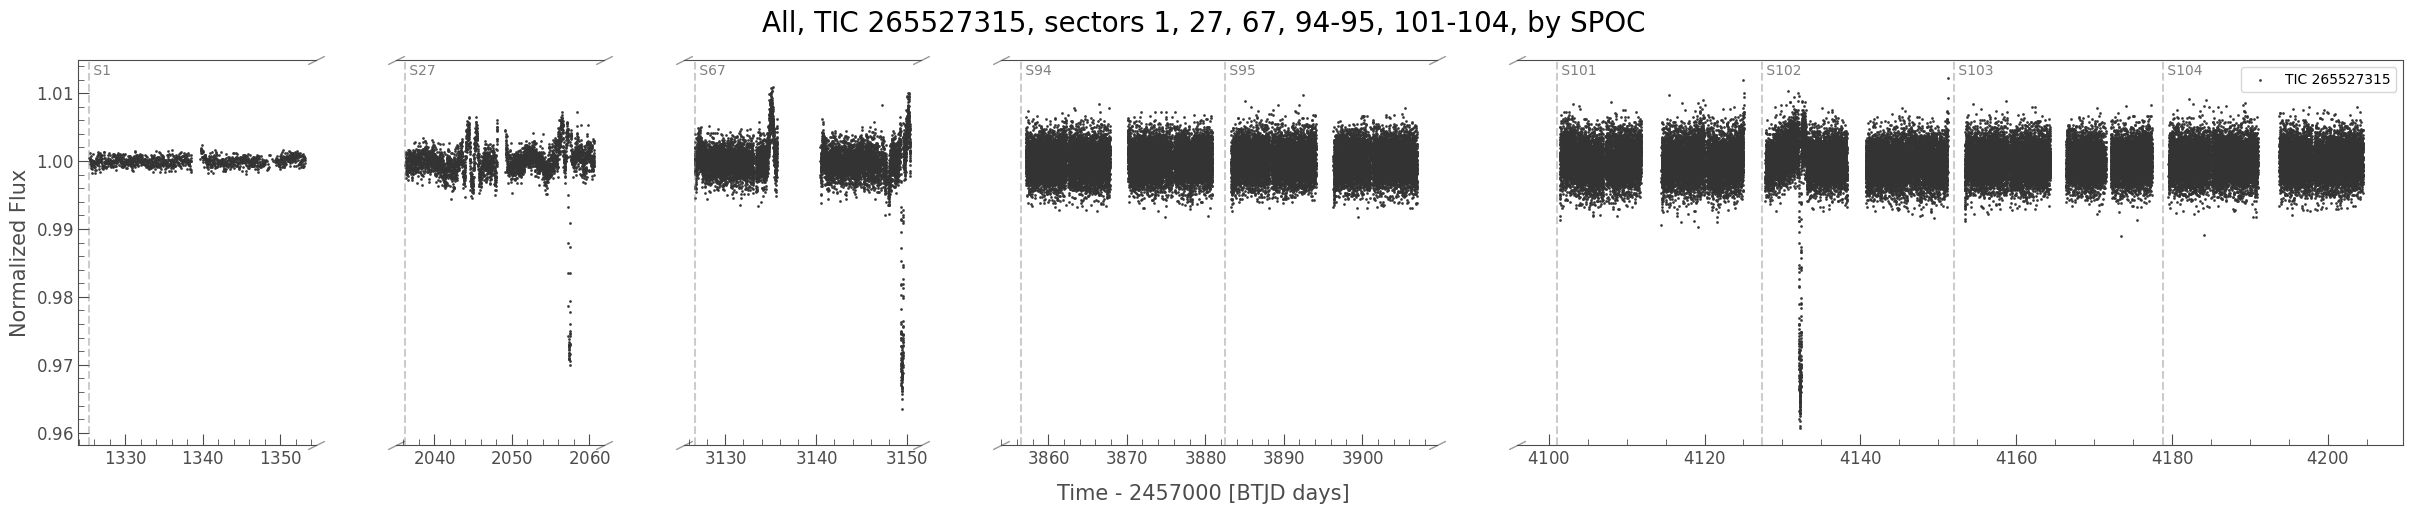

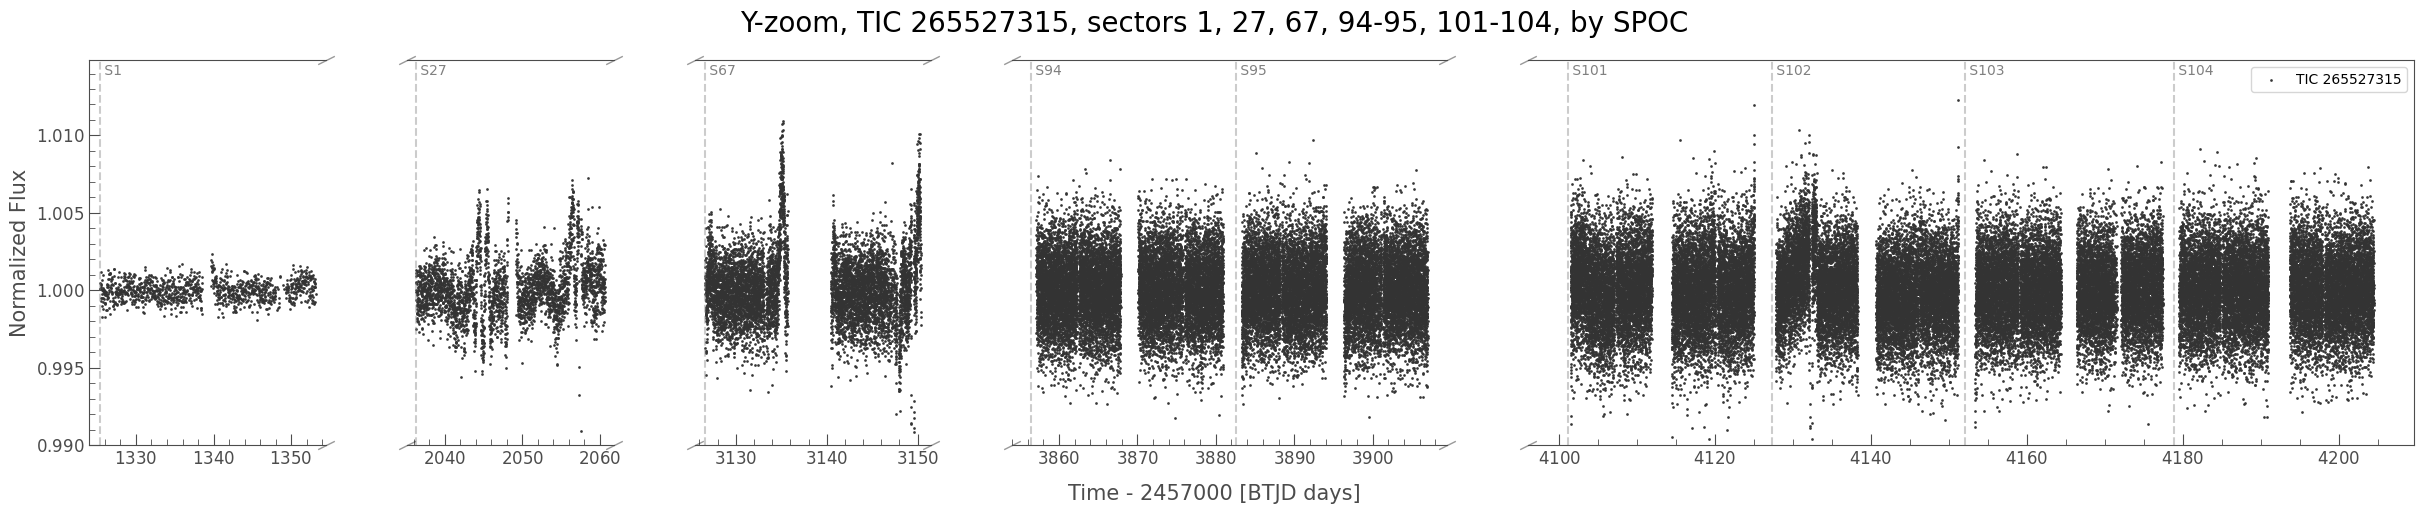

In [9]:
_lc = lke.stitch(lcc_tess, ignore_incompatible_column_warning=True)  # , corrector_func=lambda lc: lc.select_flux("sap_flux").normalize()

axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=4, alpha=0.9);
axs[0].get_figure().suptitle(f"All, {_lc.label}, sectors {lke.abbrev_sector_list(_lc)}, by {_lc.author}", fontsize=20);

axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=4, alpha=0.9);
axs[0].get_figure().suptitle(f"Y-zoom, {_lc.label}, sectors {lke.abbrev_sector_list(_lc)}, by {_lc.author}", fontsize=20);
[ax.set_ylim(0.99, None) for ax in axs];


117014

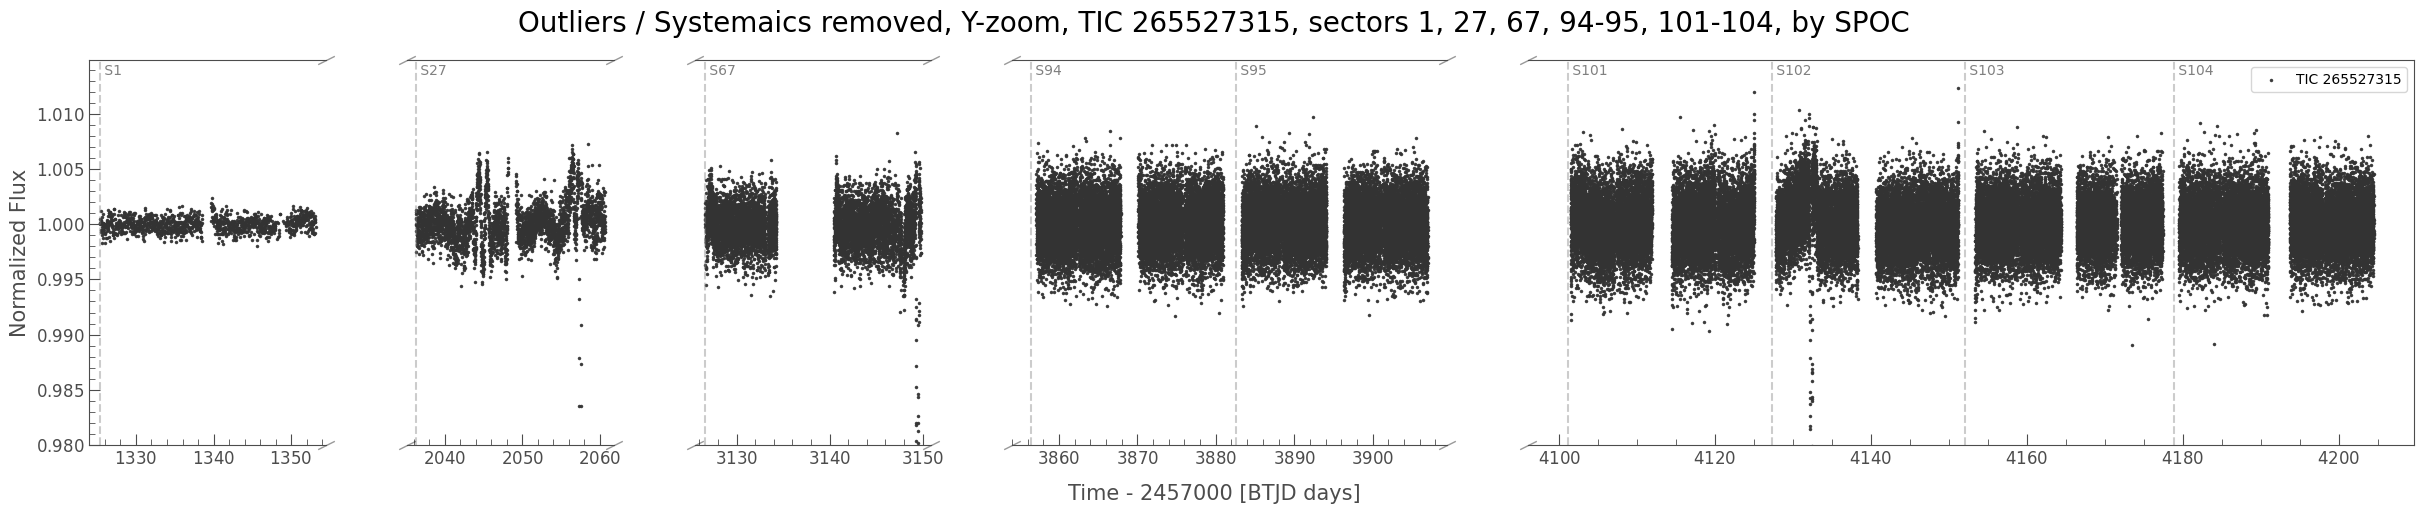

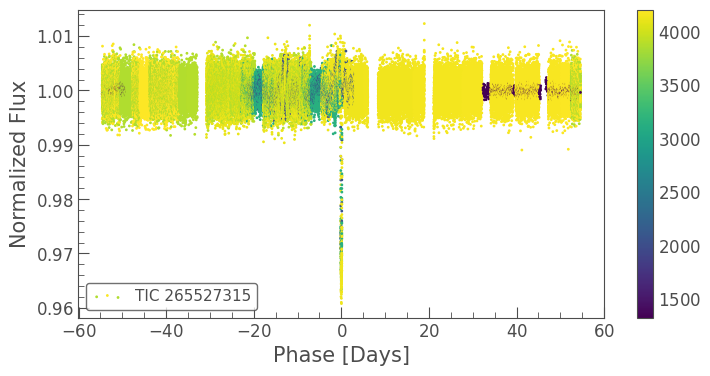

In [12]:
_lc = lke.stitch(lcc_tess, ignore_incompatible_column_warning=True)  # , corrector_func=lambda lc: lc.select_flux("sap_flux").normalize()

for xstart, xstop in [  # scattered light, and systematics
    (3134.3, 3135.9),  # S67, end of orbit sysatmics 
    (3149.8, 3150.5),  # S67, end of orbit sysatmics
    
]:
    _lc = lke.exclude_range(_lc, xstart, xstop)

axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
axs[0].get_figure().suptitle(f"Outliers / Systemaics removed, Y-zoom, {_lc.label}, sectors {lke.abbrev_sector_list(_lc)}, by {_lc.author}", fontsize=20);
[ax.set_ylim(0.98, None) for ax in axs];

_lc_f = _lc.fold(period=109.202, epoch_time=Time(4132.25, format="btjd"), )  # wrap_phase= # rough initial epoch / period to gauge usefulness of the data
ax = tplt.scatter(_lc_f, c=_lc_f.time_original.value);


# convert to mag and HJD
lc_tess = _lc

lc_tess = lke.to_flux_in_mag_by_normalization(lc_tess)
lc_tess = lke.convert_lc_time_to_hjd_utc(lc_tess, target_coord=target_coord, cache_dir=lk_download_dir)
len(lc_tess)

### Do Actual combining

TESS # data points: 117014


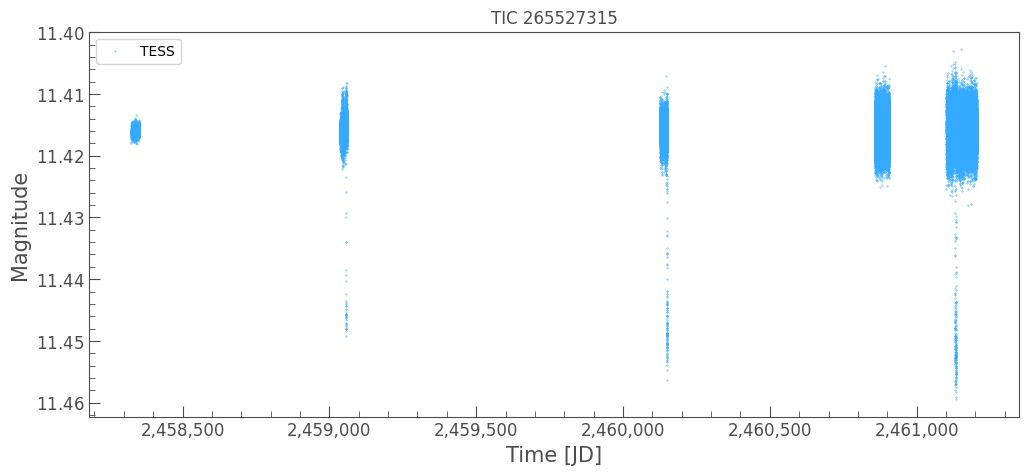

In [28]:
# Convert the data to magnitude and HJD/UTC

import lightkurve_ext_multi_sources as lkem
# reload(lkem)

lc_combined_dict = lkem.combine_multi_bands_and_shift(
    {"TESS": lc_tess, 
     # "ASAS-3": lc_asas3,
    }, 
    # shift_to="ASAS-3",
)

for k in lc_combined_dict.keys():
    print(f"{k} # data points:", len(lc_combined_dict[k]))

plot_options = lkem.get_default_plot_multi_bands_options_copy()
# for TESS plot (index 0) move it to the front
# plot_options[0][1]["zorder"] = 3  # default 2

ax = lkem.plot_multi_bands(lc_combined_dict, figsize=(12, 5), target_name=primary_name, plot_options=plot_options);
# ax.set_ylim(10.4, 10.25);

## Initial epoch / period / duration


Adopted period / epoch / duration_hr:  109.202 2461132.25 7.5


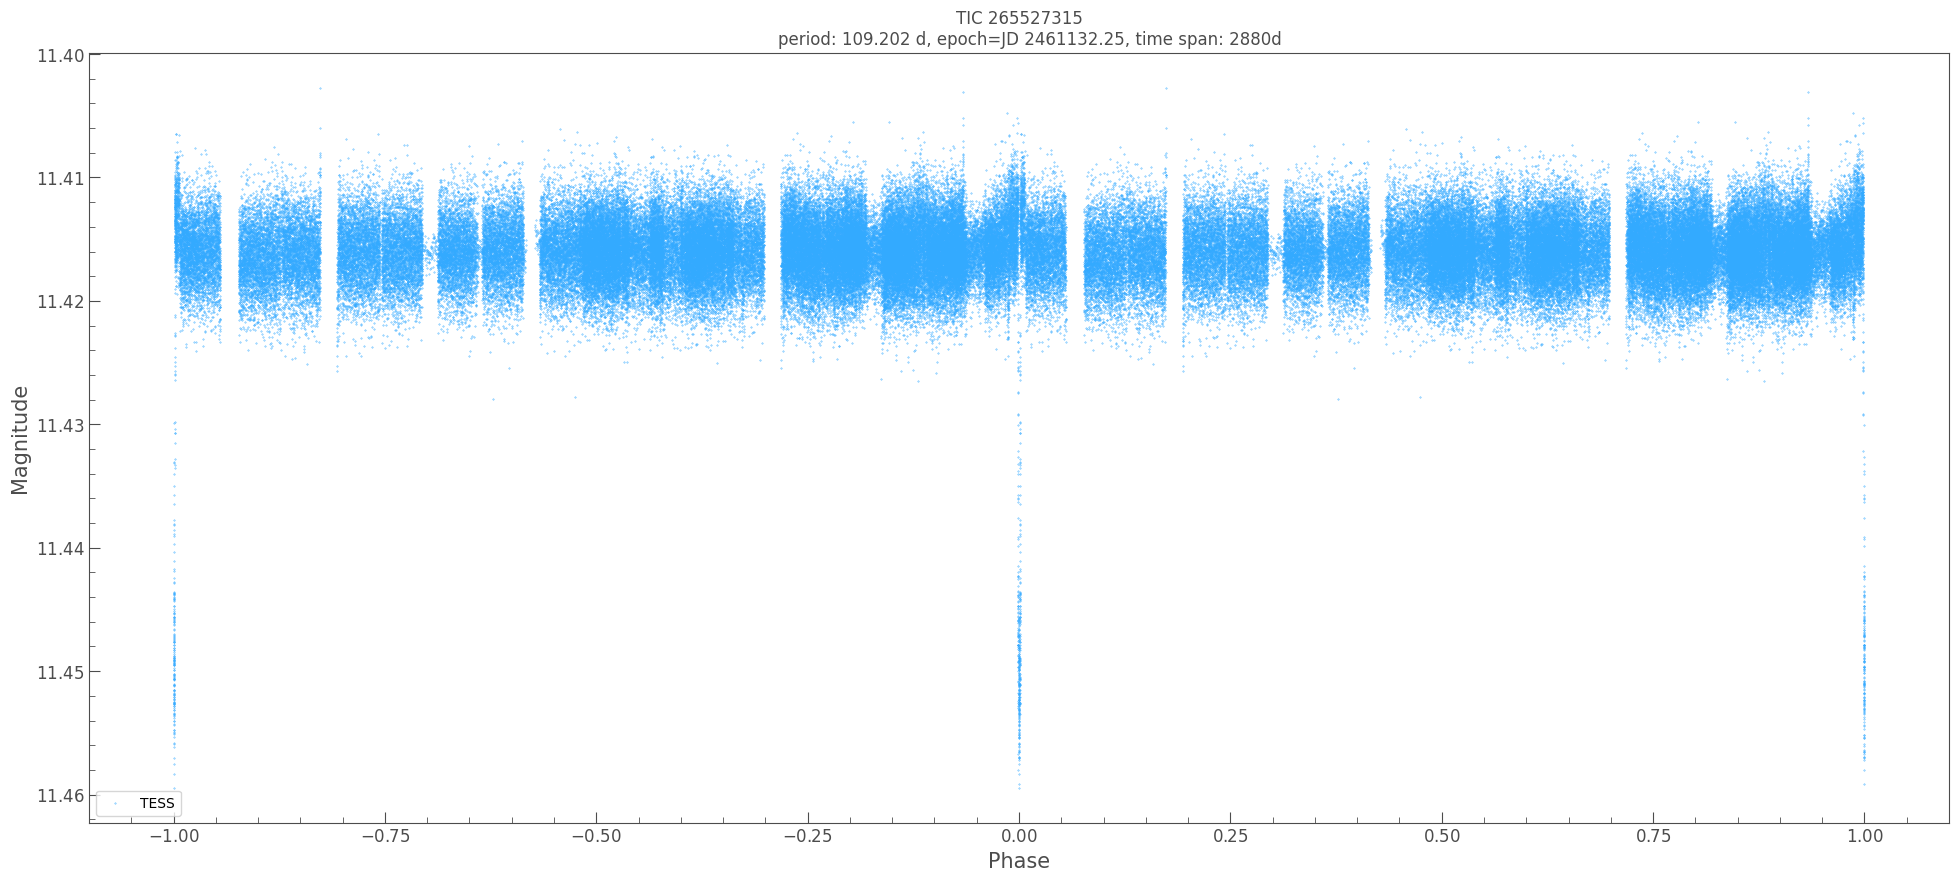

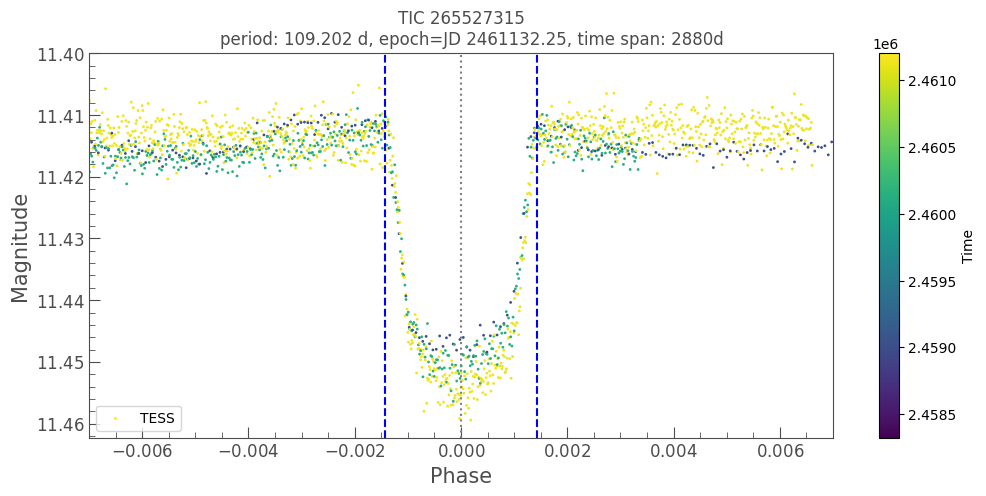

In [29]:
# reload(lkem)

# from manual inspection
# epoch=4132.25, duration_hr=7.5, period=109.202, label="dip",

period_trial = 109.202  #  
epoch_time_btjd_trial = 4132.25  # 
epoch_time_hjd_trial = round(lket.btjd_to_hjd_utc(epoch_time_btjd_trial, target_coord), 2)  # need 3 digit to ensure it does look off visually
duration_hr_min_i_trial = 7.5

# epoch_time_min_ii_btjd_trial = 
# epoch_time_min_ii_hjd_trial = round(lket.btjd_to_hjd_utc(epoch_time_min_ii_btjd_trial, target_coord), 2)  # need 3 digit to ensure it does look off visually
# duration_hr_min_ii_trial = 


print("Adopted period / epoch / duration_hr: ", period_trial, epoch_time_hjd_trial, duration_hr_min_i_trial)  # , duration_hr_min_ii_trial

# --- Plot them to verify ---

plot_options = lkem.get_default_plot_multi_bands_options_copy()

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_trial,
    epoch=Time(epoch_time_hjd_trial   , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(24, 10),
    target_name=primary_name,
    plot_options=plot_options,
);
ax.legend(loc="lower left");
ylim = (None, None)
ax.set_ylim(*ylim);

# zoom plot Min I
# - make TESS more visible:  larger dots
plot_options_zoom = lkem.get_default_plot_multi_bands_options_copy()
plot_options_zoom[0][1]["s"] = 1
plot_options_zoom[0][1]["c"] = "_time_"

# plot_options_zoom[0][1]["zorder"] = 3  # move to the front, default 2
# plot_options_zoom[1][1].update(dict(marker='o', markersize=4))


ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_trial,
    epoch=Time(epoch_time_hjd_trial, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_i_trial  ,  # for plotting only
    figsize=(12, 5), 
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
ax.axvline(0, c="gray", linestyle="dotted");
ax.set_xlim(-0.007, 0.007);  # to see primary in details
ax.set_ylim(*ylim);


# # zoom plot Min II
# ax, lc_f_res = lkem.fold_n_plot_multi_bands(
#     lc_combined_dict,
#     period=period_trial,
#     epoch=Time(epoch_time_min_ii_hjd_trial, format="jd", scale="utc"),
#     phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
#     target_name=primary_name,
#     duration_hr=duration_hr_min_ii_trial  ,  # for plotting only
#     figsize=(12, 5),
#     plot_options=plot_options_zoom,
#     # mag_shift_precision=2,
# );
# ax.legend(loc="lower left");
# ax.axvline(0, c="gray", linestyle="dotted");
# ax.set_xlim(-0.007, 0.007);  # to see primary in details
# ax.set_ylim(9.97, 9.952);


## Period refinement with MCMC - N/A

- skipped. the inital fit is good enough

In [ ]:
# _lc = lke.stitch_lc_dict(lke.get_lc_dict_subset(lc_combined_dict, "TESS"), normalize=True).remove_nans()  

# lc_f_min_i = _lc.fold(epoch_time=epoch_time_hjd_trial, period=period_trial, normalize_phase=True)
# lc_f_min_i = lc_f_min_i.truncate((0 - duration_hr_min_i_trial / 24 * 1.5) / period_trial, (0 + duration_hr_min_i_trial /24 * 1.5) / period_trial)
# # lc_f_min_i = lc_f_min_i.truncate(None, 1.2, column="flux")  # crude outlier removal
# ax1 = tplt.scatter(lc_f_min_i, c=lc_f_min_i.time_original.value, s=25);
# # ax1 = tplt.errorbar(lc_f_min_i);

In [ ]:
# from types import SimpleNamespace

# import sys
# if "../eb_with_diff_sb_period/etv/" not in sys.path:  # for etvp
#     sys.path.append("../eb_with_diff_sb_period/etv/")

# import etv_functions_with_period as etvp
# import etv_functions
# # reload(etv_functions)

# lc_f = lc_f_min_i

# # # median flux, -eclipse depth, t0, related to duration, related to shape (U or V) 
# # # t0 in normalixed phase
# start_vals = [1.005, -0.07, 0, 0.0028, 2.5]


# # convert lc to the form needed by fit etv_functions
# lc_f_data = SimpleNamespace(time=lc_f.time_original.value, phase=lc_f.time.value, flux=np.array(lc_f.flux.value), err=np.array(lc_f.flux_err.value))
# etv_functions.plot_initial_guess_interactive(lc_f_data, None, None, None, "0", *start_vals)

### Final MCMC fit with the best initial period

In [ ]:
# mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p, fit_params_p_stats  = etvp.run_mcmc_initial_fit_p(
#     lc_f_data, 
#     [1.005, -0.07, epoch_time_hjd_trial, 0.0028, 2.5, period_trial],
#     # nruns=20, discard=1,
#     nruns=3000, discard=1000,
#     autocorr_time_kwargs=dict(tol=20),  # the emcee defaults tol=50 seems to be too strict for our use case, tol of ~10 - 20 seems to be sufficient    
#     pool=-2, 
#     plot_chains=True, plot_autocorrelation=True, plot=True, 
#     also_return_stats=True,
# )

# print("mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p = " + ", ".join([str(v) for v in [mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p]]))
# print("std_t0:", fit_params_p_stats["std_t0"])
# print("std_p:", fit_params_p_stats["std_p"])


## Final period / epoch / duration

Adopted period / epoch / duration_hr:  109.202 2461132.25 7.5


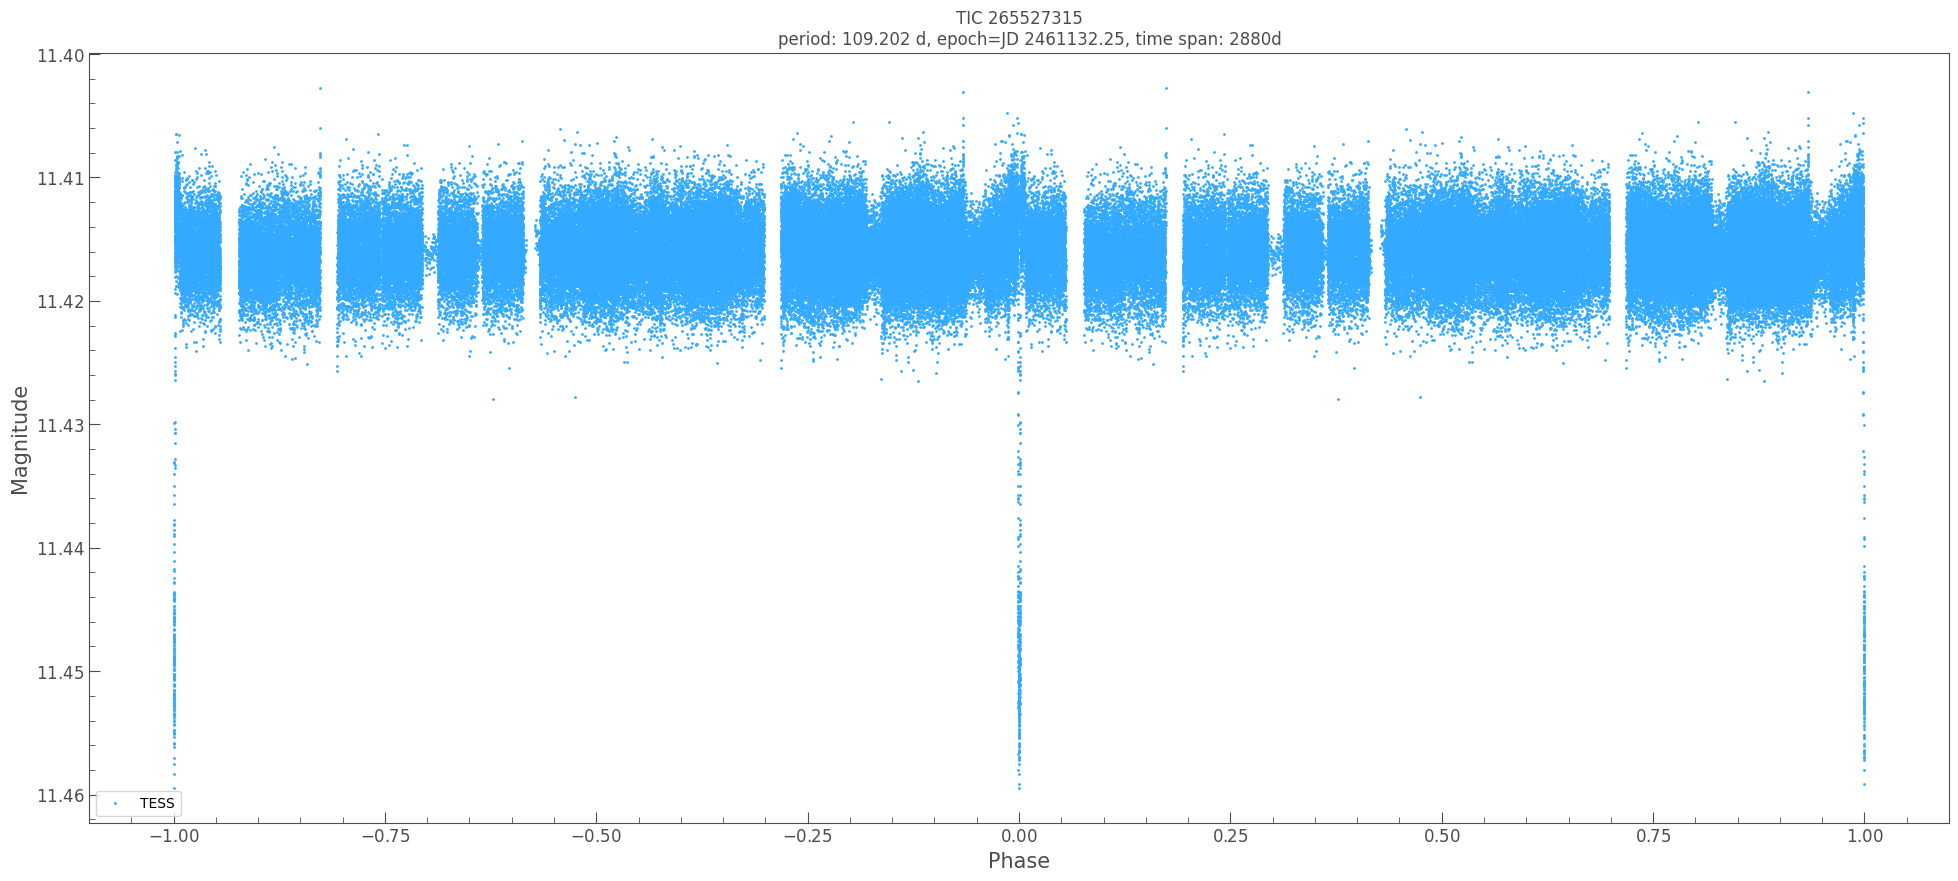

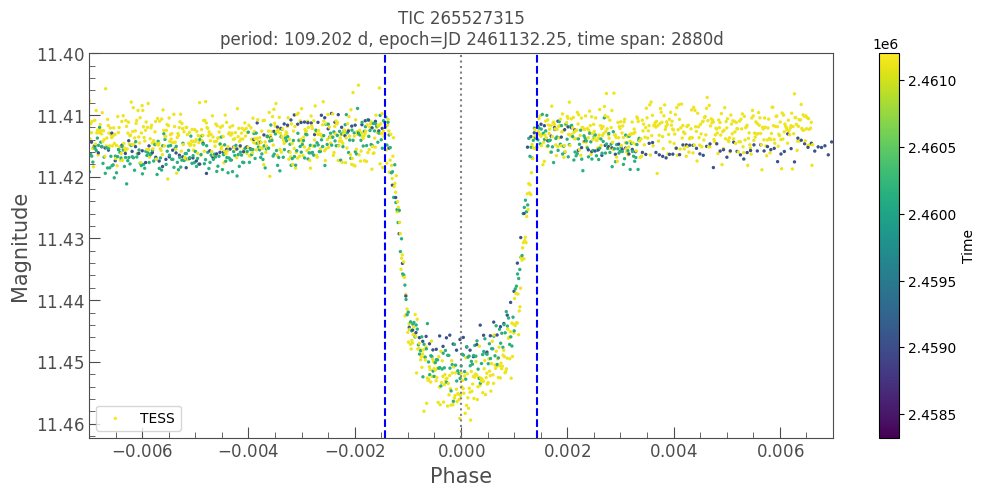

In [31]:
# reload(lkem)
from decimal import Decimal

period_final = period_trial
epoch_time_hjd_final = epoch_time_hjd_trial
duration_hr_min_i_final = duration_hr_min_i_trial 

# epoch_time_min_ii_hjd_final = epoch_time_min_ii_hjd_trial
# epoch_phase_min_ii_final   = abs(epoch_time_min_ii_hjd_final - float(epoch_time_hjd_final)  ) / period_final  % 1
# epoch_phase_min_ii_final  = round(epoch_phase_min_ii_final, 4)  # precsion from eyeballing zoomed plot
# duration_hr_min_ii_final = duration_hr_min_ii_trial


print("Adopted period / epoch / duration_hr: ", period_final, epoch_time_hjd_final, duration_hr_min_i_final)  # ,  epoch_phase_min_ii_final,  duration_hr_min_ii_final

# --- plot to verify ---

plot_options = lkem.get_default_plot_multi_bands_options_copy()
plot_options[0][1]["s"] = 1

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final   , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(24, 10),
    target_name=primary_name,
    plot_options=plot_options,
);
ax.legend(loc="lower left");
ylim = (None, None)
ax.set_ylim(*ylim);

# zoom plot Min I
# - make TESS more visible:  larger dots
plot_options_zoom = lkem.get_default_plot_multi_bands_options_copy()
plot_options_zoom[0][1]["s"] = 2
plot_options_zoom[0][1]["c"] = "_time_"


ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_i_final  ,  # for plotting only
    figsize=(12, 5),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
ax.axvline(0, c="gray", linestyle="dotted");
ax.set_xlim(-0.007, 0.007);  # to see primary in details
ax.set_ylim(*ylim);

# ax = tplt.scatter(lc_f_res["TESS"].truncate(-0.005, 0.005), c="#3AF");
# ax.axvline(0, c="gray", linestyle="dotted");
# ax.set_title(f"Min I: {epoch_time_hjd_final}");

# # zoom plot Min II
# ax, lc_f_res = lkem.fold_n_plot_multi_bands(
#     lc_combined_dict,
#     period=period_final,
#     epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
#     phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
#     target_name=primary_name,
#     duration_hr=duration_hr_min_ii_final  ,  # for plotting only
#     duration_midpoint_phase=epoch_phase_min_ii_final,
#     figsize=(12, 5),
#     plot_options=plot_options_zoom,
#     # mag_shift_precision=2,
# );
# ax.legend(loc="lower left");
# ax.axvline(epoch_phase_min_ii_final, c="gray", linestyle="dotted");
# ax.set_xlim(epoch_phase_min_ii_final - 0.008, epoch_phase_min_ii_final + 0.008);  # to see secondary in details
# ax.set_ylim(9.97, 9.952);


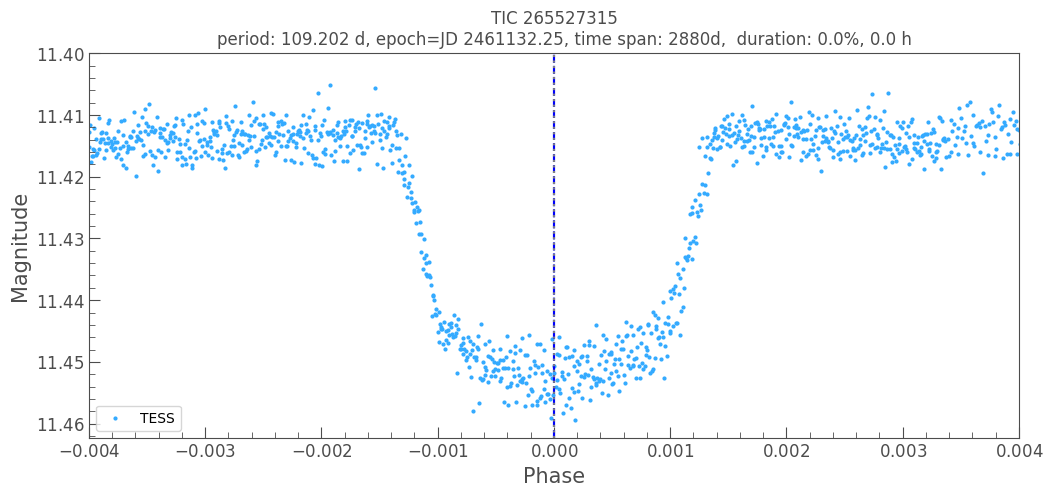

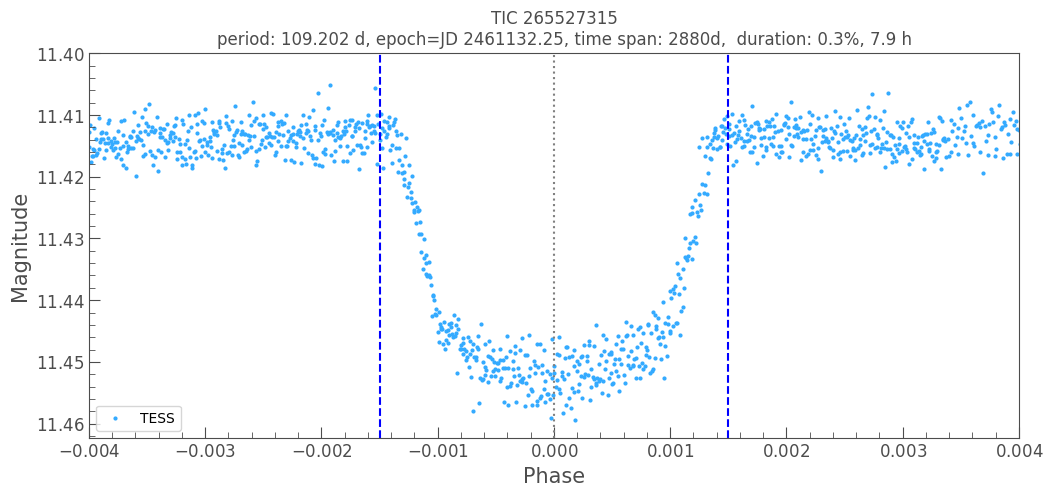

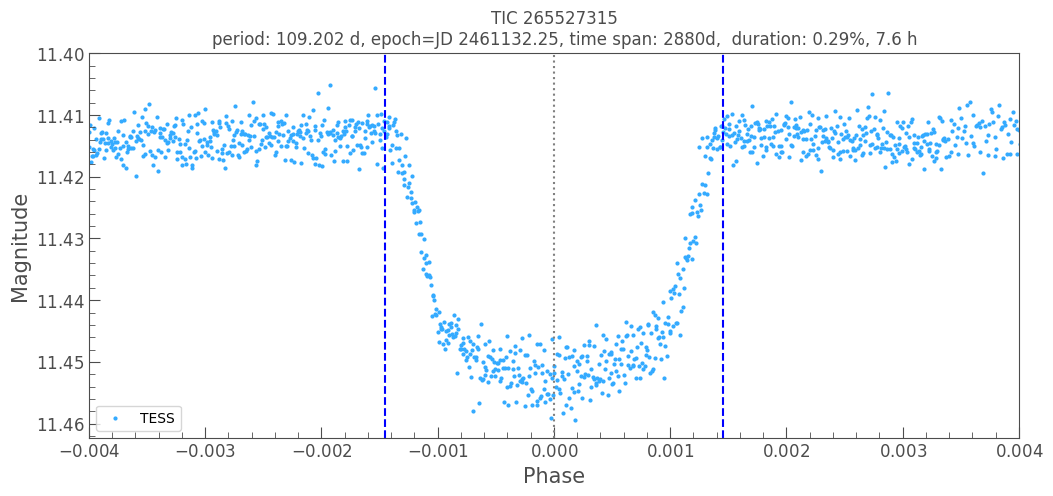

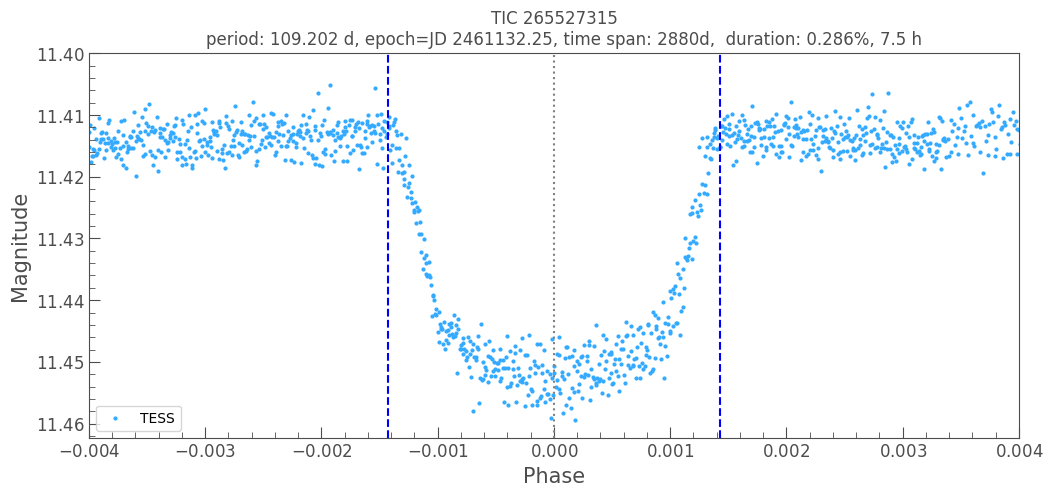

In [33]:
# demonstrate the precision difference in duration percentage 
# - 2 digits for percetnarge would be appropriate
for _precision in [0, 1, 2, 3]: 
    _dur_pct = round(100 * duration_hr_min_i_final / 24 / float(period_final), _precision)
    _dur_hr = _dur_pct /100 * 24 * float(period_final)
    # zoom plot Min I
    # - make TESS more visible:  larger dots
    plot_options_zoom = lkem.get_default_plot_multi_bands_options_copy()
    plot_options_zoom[0][1]["s"] = 4
    ax, lc_f_res = lkem.fold_n_plot_multi_bands(
        lc_combined_dict,
        period=period_final,
        epoch=Time(epoch_time_hjd_final  , format="jd", scale="utc"),
        phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
        target_name=primary_name,
        duration_hr=_dur_hr,  # for plotting only
        figsize=(12, 5),
        plot_options=plot_options_zoom,
        # mag_shift_precision=2,  #
    );
    ax.set_ylim(*ylim);
    ax.legend(loc="lower left");
    ax.axvline(0, c="gray", linestyle="dotted");
    ax.set_xlim(-0.004, 0.004);  # to see primary in details
    ax.set_title(ax.get_title() + f",  duration: {_dur_pct}%, {_dur_hr:.1f} h");
    # print(_dur_pct, _dur_hr, duration_hr_min_i_final) 

## Determine Amplitude (TESS)


Min I mag # num data points: 15
['11.4160', '11.4527']


(np.float64(0.037),)

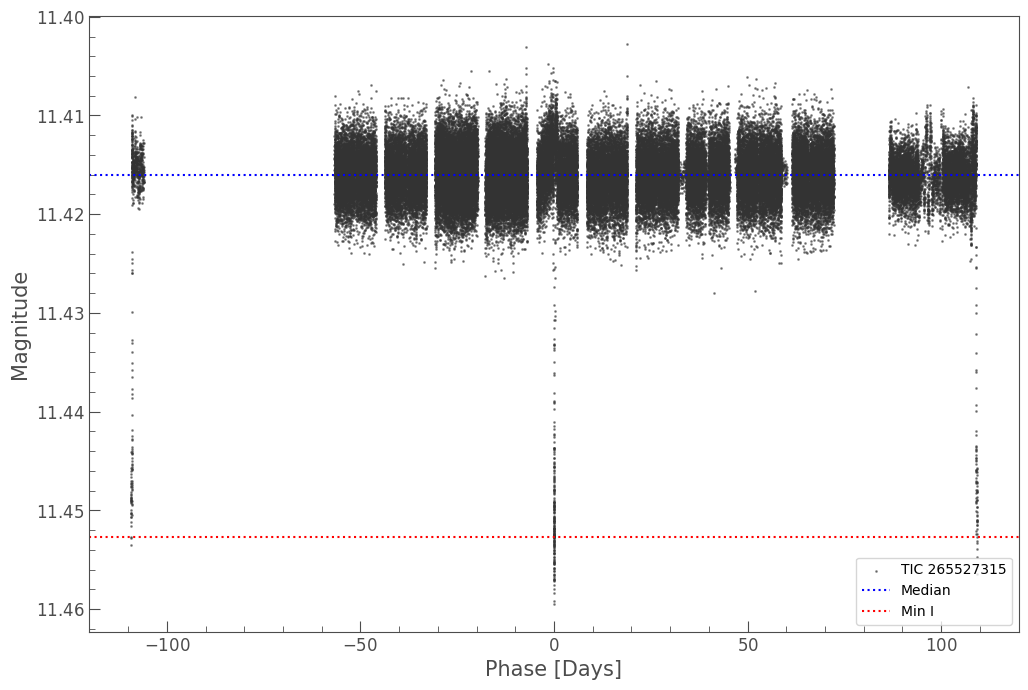

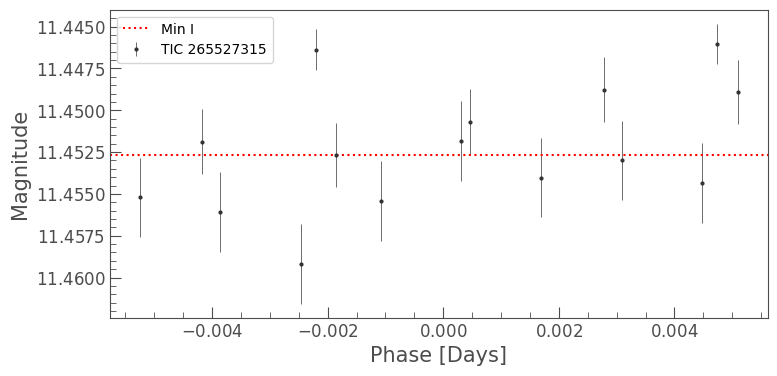

In [39]:
# %matplotlib widget
%matplotlib inline

# From TESS data
lc = lc_combined_dict["TESS"]

# max_flux_mag = lc.flux.min().value  #
# min_flux_mag = lc.flux.max().value
median_flux_mag = np.nanmedian(lc.flux.value)

# no max neded, medain is basically max
# lc_zoom_max = lc.fold(epoch_time=epoch_time_hjd_final + 0.75, period=period_final).truncate(0 - 1 /24/60, 0 + 1 /24/ 60)  
# print("Max mag # num data points:", len(lc_zoom_max))
# max_flux_mag = np.nanmedian(lc_zoom_max.flux.value)

lc_zoom_min = lc.fold(epoch_time=epoch_time_hjd_final, period=period_final).truncate(0 - 8 /24/60, 0 + 8 /24/ 60)
print("Min I mag # num data points:", len(lc_zoom_min))
min_flux_mag = np.nanmedian(lc_zoom_min.flux.value)

# lc_zoom_min_ii = lc.fold(epoch_time=epoch_time_min_ii_hjd_final, period=period_final).truncate(0 - 8 /24/60, 0 + 8 /24/ 60)
# print("Min II mag # num data points:", len(lc_zoom_min_ii))
# min_ii_flux_mag = np.nanmedian(lc_zoom_min_ii.flux.value)


lc_f = lc.fold(epoch_time=epoch_time_hjd_final, period=period_final * 2)  # 2x period plot
ax = tplt.lk_ax(figsize=(12, 8))
ax = tplt.scatter(lc_f, ax=ax, alpha=0.5);
# ax.axhline(max_flux_mag, c="purple", linestyle="--", label="Max")
ax.axhline(median_flux_mag, c="blue", linestyle="dotted", label="Median")
ax.axhline(min_flux_mag, c="red", linestyle="dotted", label="Min I")
# ax.axhline(min_ii_flux_mag, c="orange", linestyle="dotted", label="Min II")
ax.legend(loc="lower right");
# ax.set_xlim(-0.5, 0.5); 
ax.set_ylim(*ylim);


ax = tplt.errorbar(lc_zoom_min, marker="o");
ax.axhline(min_flux_mag, c="red", linestyle="dotted", label="Min I")
# ax.set_ylim(*ylim);
ax.legend();

# ax = tplt.errorbar(lc_zoom_min_ii, marker="o");
# ax.axhline(min_ii_flux_mag, c="red", linestyle="dotted", label="Min II")
# ax.legend(loc="lower right");

print([f"{v:.4f}" for v in [median_flux_mag, min_flux_mag]])  # , min_ii_flux_mag


# # TESS only data, to report mean V mag and ampitude in TESS
# mean_flux_v_mag = np.round(rs_all_cols["Vmag"][0], 2)  # V converted from Gaia DR3 - here I use other sources

# amp_flux_mag = np.round(np.abs(float(min_flux_mag - max_flux_mag)) , 3)  # in TESS band, probably don't have 4 digit precison

amp_min_i_flux_mag = np.round(np.abs(float(min_flux_mag - median_flux_mag)) , 3)  # does not look like it has 3 digit precision given the out-of-eclipse variation

# amp_min_ii_flux_mag = np.round(np.abs(float(min_ii_flux_mag - median_flux_mag)) , 3)  

(amp_min_i_flux_mag, )  # amp_flux_mag, amp_min_ii_flux_mag

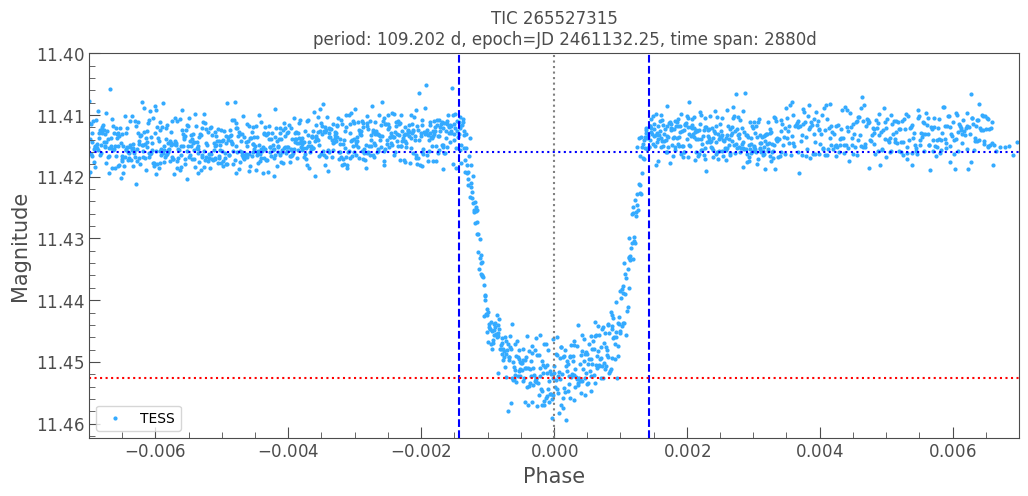

In [36]:
ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_i_final  ,  # for plotting only
    figsize=(12, 5),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
ax.axvline(0, c="gray", linestyle="dotted");
ax.set_xlim(-0.007, 0.007);  # to see primary in details
ax.set_ylim(*ylim);
ax.axhline(median_flux_mag, c="blue", linestyle="dotted", label="Median");
ax.axhline(min_flux_mag, c="red", linestyle="dotted", label="Min I");


# ax, lc_f_res = lkem.fold_n_plot_multi_bands(
#     lc_combined_dict,
#     period=period_final,
#     epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
#     phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
#     target_name=primary_name,
#     duration_hr=duration_hr_min_ii_final  ,  # for plotting only
#     duration_midpoint_phase=epoch_phase_min_ii_final,
#     figsize=(12, 5),
#     plot_options=plot_options_zoom,
#     # mag_shift_precision=2,
# );
# ax.legend(loc="lower left");
# ax.axvline(epoch_phase_min_ii_final, c="gray", linestyle="dotted");
# ax.set_xlim(epoch_phase_min_ii_final - 0.01, epoch_phase_min_ii_final + 0.01);  # to see secondary in details
# ax.set_ylim(9.97, 9.952);
# ax.axhline(median_flux_mag, c="blue", linestyle="dotted", label="Median");
# ax.axhline(min_ii_flux_mag, c="red", linestyle="dotted", label="Min II");


### Maximum / Median magnitude in V 

- no GCPD data

In [40]:
median_flux_vmag = 12.17  # from Gaia DR3, SIMBAD: 12.14 from UCAC4, ASAS-SN pre-computed photomery median: 12.177
median_flux_vmag

12.17

## Plots for VSX

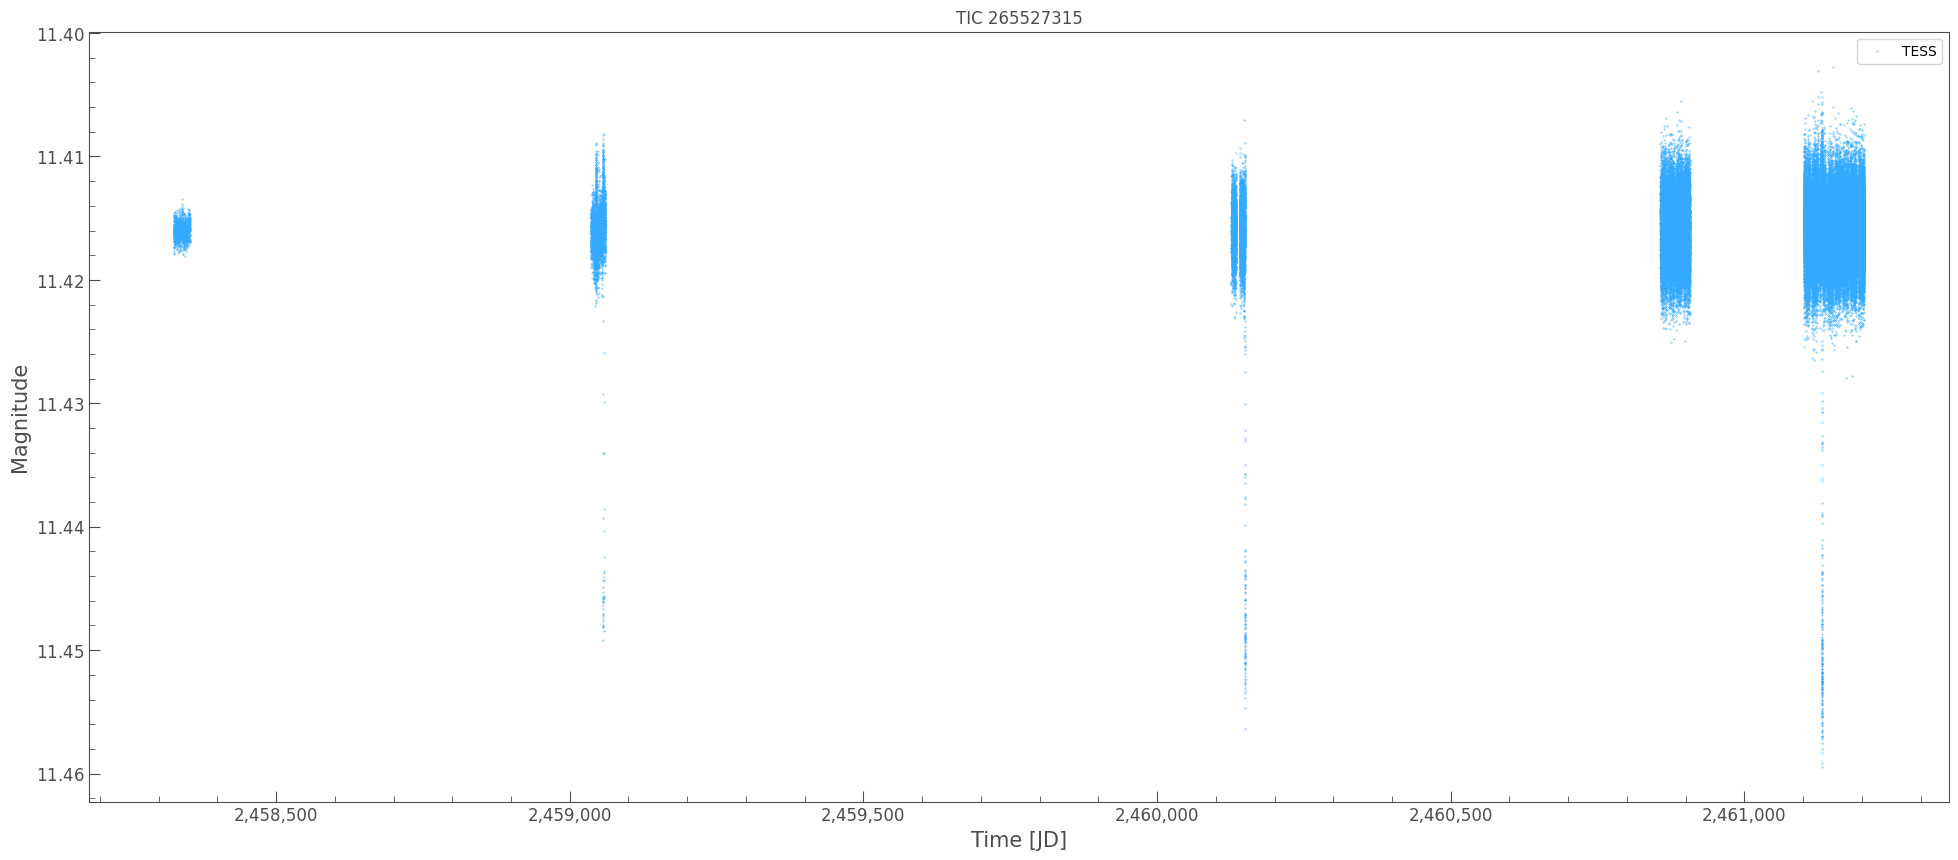

In [49]:
# reload(lkem)
# Not needed
plot_options = lkem.get_default_plot_multi_bands_options_copy()
# plot_options[0][1]["zorder"] = 4

ax = lkem.plot_multi_bands(lc_combined_dict, figsize=(24, 10), target_name=primary_name, plot_options=plot_options);
# ax.set_title(ax.get_title() + "");

#### Phase Plot



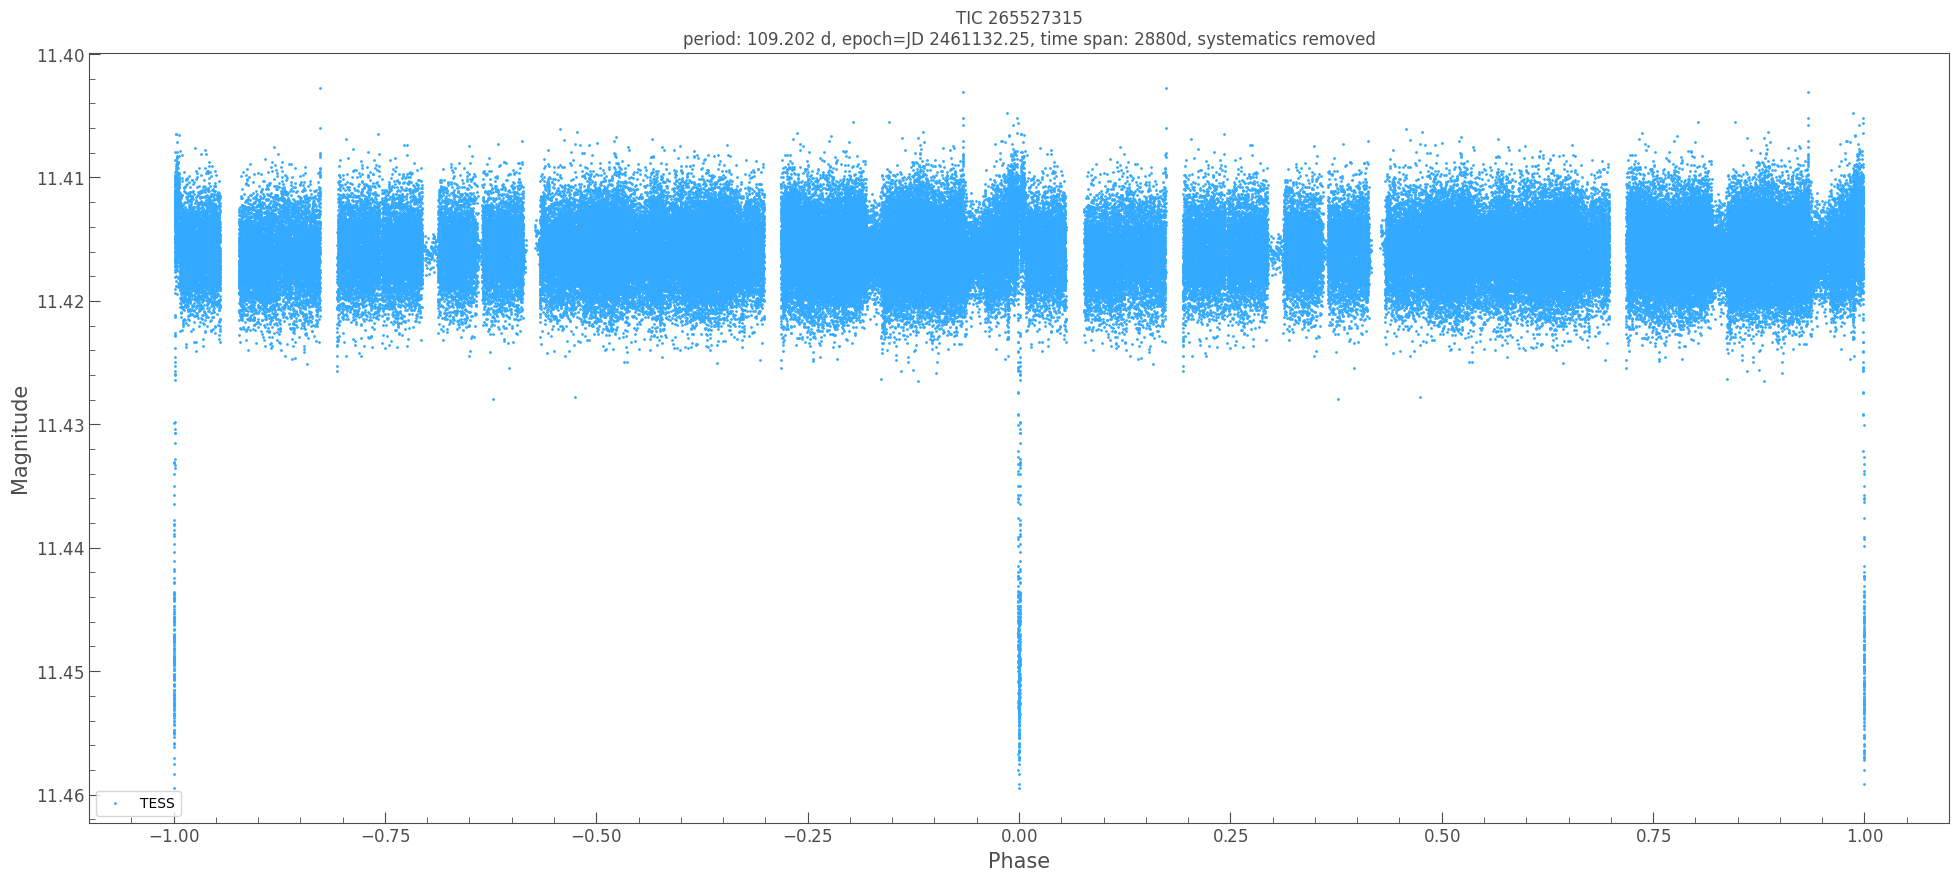

In [50]:
plot_options = lkem.get_default_plot_multi_bands_options_copy()  # use scatter plot , as errrobar is too busy
plot_options[0][1].update(dict(s=1, ))  # make dots larger

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final   , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(24, 10),
    target_name=primary_name,
    plot_options=plot_options,
);
ax.legend(loc="lower left");
ylim = (None, None)  # hide the outliers that are too bright, mostly in ASAS-SN g
ax.set_ylim(*ylim);
ax.set_title(ax.get_title() + ", systematics removed");


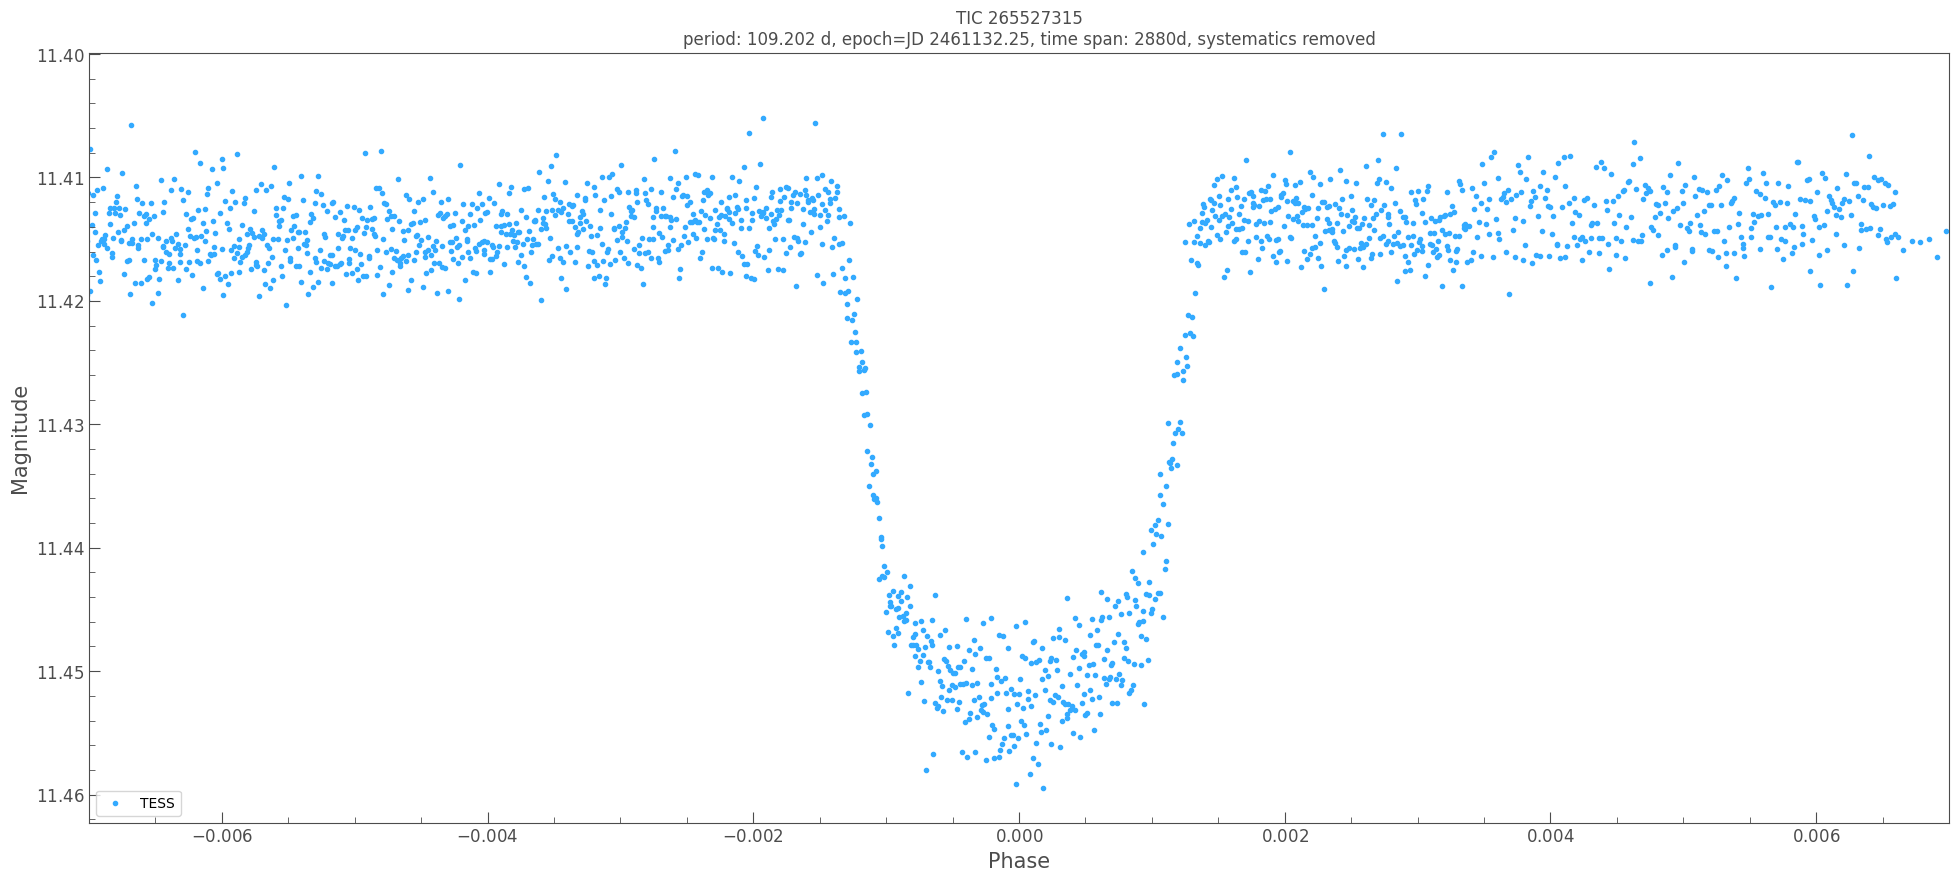

In [70]:
# zoom plot Min I
# - make TESS more visible:  larger dots
plot_options_zoom = lkem.get_default_plot_multi_bands_options_copy()
plot_options_zoom[0][1].update(dict(s=9))
plot_options_zoom[1][1].update(dict(marker='o', markersize=9))


ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    # duration_hr=duration_hr_min_i_final  ,  # for plotting only
    figsize=(24, 10),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
# ax.axvline(0, c="gray", linestyle="dotted");
ax.set_xlim(-0.007, 0.007);  # to see primary in details
ax.set_ylim(*ylim);
ax.set_title(ax.get_title() + ", systematics removed");


# # zoom plot Min II
# ax, lc_f_res = lkem.fold_n_plot_multi_bands(
#     lc_combined_dict,
#     period=period_final,
#     epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
#     phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
#     target_name=primary_name,
#     # duration_hr=duration_hr_min_ii_final ,  # for plotting only
#     # duration_midpoint_phase=epoch_phase_min_ii_final,
#     figsize=(24, 10),
#     plot_options=plot_options_zoom,
#     # mag_shift_precision=2,
# );
# ax.legend(loc="lower left");
# # ax.axvline(epoch_phase_min_ii_final, c="gray", linestyle="dotted");
# ax.set_xlim(epoch_phase_min_ii_final - 0.01, epoch_phase_min_ii_final + 0.01);  # to see secondary in details
# ax.set_ylim(9.97, 9.952);
# ax.set_title(ax.get_title() + ", systematics removed");


### JD Plot (TESS) - N/A

In [57]:
# # to shwo the eclipses and the time without eclipses
# axs = tplt.plot_skip_data_gap(lc_combined_dict["TESS"], figsize=(30, 4), s=2, c="#3AF", label=lkem.get_label_of_source(lc_combined_dict, "TESS", mag_shift_precision=2));
# axs[0].get_figure().suptitle(f"{primary_name}");
# [ax.set_ylim(9.87, 9.85) for ax in axs];  # truncating Min I

## VSX Report Table

In [44]:
def report_to_df(report):
    df = pd.DataFrame()
    df["Field"] = report.keys()
    df["Value"] = report.values()
    return df


def vsx_phase(phase):
    # the phase I used above is from [-0.5, +0.5]
    # convert to the phase [0, 1[ used by VSX
    if phase < -0.5 or phase > 0.5:
        raise ValueError(f"Input phase needs to be in [-0.5, 0.5] range. Actual: {phase}")
    if phase >= 0:
        return phase 
    else: 
        return 1 + phase


In [48]:
import bibs_utils
# reload(bibs_utils)
BIBS = bibs_utils.BIBS


other_names = "UCAC4 130-178609,2MASS J21282553-6406106" # in ExoFOP and SIMBAD
other_names +=",WISEA J212825.47-640610.9"  # ExoFOP + Vizier -- https://vizier.cfa.harvard.edu/viz-bin/VizieR-5?-ref=VIZ6a84a0b01c5647&-out.add=.&-source=II/328/allwise&AllWISE===J212825.47-640610.9
other_names += ",GSC 09111-00812"  # other useful SIMBAD names  -- https://vizier.cfa.harvard.edu/viz-bin/VizieR-5?-ref=VIZ6a84a1e31c9912&-out.add=.&-source=I/255/out&GSC=0911100812


remarks = (
    f"""Period might be twice the value given."""
    f""" SB per {BIBS.GAIA_DR3_NSS_B}."""
)

# Not neeed for initial submission:
# - Type, period, epoch, eclipse duration from TESS data. Amplitude from TESS data.
revision_comment = f"Maximum magnitude derived from Gaia DR3. Spectral type from {BIBS.GAIA_DR3_ASTROPHY_B}. Gaia DR3 position."


vsx_report = dict(
    Position=f"{target_coord.ra.value:.5f}, {target_coord.dec.value:.5f}",  # VSX coordinate precision
    Primary_Name=primary_name,
    Other_Names=other_names,
    Variable_Type="EA",
    Spectral_Type="K",  # Gaia DR3 astrophysical
    Spectral_Type_Uncertain=False,
    Maximum_Magnitude=f"{median_flux_vmag}",  # from Gaia DR3
    Maximum_Magnitude_band="V",
    Minimum_Magnitude=f"{amp_min_i_flux_mag}",
    Minimum_Magnitude_band="TESS",  
    Minimum_Is_Amplitude=True,
    Period=f"{period_final}",  
    Period_Uncertain=False,
    Epoch=f"{epoch_time_hjd_final}",  
    Rise_Duration_Pct=f"{100 * duration_hr_min_i_final / 24 / float(period_final):.2f}",  # 1 decimal point is enough visually
    Discoverer="Sam Lee, Planet Hunters TESS Collaboration",  # PHT Talk: https://www.zooniverse.org/projects/nora-dot-eisner/planet-hunters-tess/talk/subjects/121441474
    Remarks=remarks,
    Revision_Comment=revision_comment,
    Reference0_Name=BIBS.TESS_N,  
    Reference0_Bib=BIBS.TESS_B,
    Reference1_Name=BIBS.TESS_SPOC_N,  
    Reference1_Bib=BIBS.TESS_SPOC_B,
    Reference2_Name=BIBS.GAIA_DR3_ASTROPHY_N,
    Reference2_Bib=BIBS.GAIA_DR3_ASTROPHY_B,
    Reference3_Name=BIBS.GAIA_DR3_NSS_N,
    Reference3_Bib=BIBS.GAIA_DR3_NSS_B,
)


def print_long_fields(report):
    other_names_list = report["Other_Names"].split(",")
    print("Other Names (1 line each):")
    print("\n".join(other_names_list))
    print("")
    print(report["Remarks"])
    print("")
    print(report["Revision_Comment"])

print_long_fields(vsx_report)
with pd.option_context('display.max_colwidth', None):
    display(report_to_df(vsx_report))


print("""
tic265527315_phase_plot_eclipses.png : EA Phase Plot - EA Phase Plot from TESS data, systematics removed.
tic265527315_phase_plot_eclipses_zoom_min_i.png : EA Phase Plot (Min I Zoom) - EA Phase Plot from TESS data. Zoomed around Min I.
""")


Other Names (1 line each):
UCAC4 130-178609
2MASS J21282553-6406106
WISEA J212825.47-640610.9
GSC 09111-00812

Period might be twice the value given. SB per 2022yCat.1357....0G.

Maximum magnitude derived from Gaia DR3. Spectral type from 2023A&A...674A..26C. Gaia DR3 position.


,Field,Value
0,Position,"322.10638, -64.10294"
1,Primary_Name,TIC 265527315
2,Other_Names,"UCAC4 130-178609,2MASS J21282553-6406106,WISEA J212825.47-640610.9,GSC 09111-00812"
3,Variable_Type,EA
4,Spectral_Type,K
5,Spectral_Type_Uncertain,False
6,Maximum_Magnitude,12.17
7,Maximum_Magnitude_band,V
8,Minimum_Magnitude,0.037
9,Minimum_Magnitude_band,TESS



tic265527315_phase_plot_eclipses.png : EA Phase Plot - EA Phase Plot from TESS data, systematics removed.
tic265527315_phase_plot_eclipses_zoom_min_i.png : EA Phase Plot (Min I Zoom) - EA Phase Plot from TESS data. Zoomed around Min I.

